In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.compose import make_column_transformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import numpy as np
import mlflow
import mlflow.xgboost
from fastapi import FastAPI



# Import Dataset

In [2]:
train = pd.read_csv("../data/df01.csv")
test = pd.read_csv("../data/df02.csv")

# Dataset Exploration

## Dataset Summary

In [3]:
train.shape

(27729, 18)

In [4]:
train.head(1)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,date
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,2008-05-05


There are 18 columns in this dataset which are divided into four sections: (1) client information (age to loan), (2) current campaigning details (contact until duration and date), (3) previous campaigning details (campaign until poutcome), and (4) the variable of interest: subscription (y).  For this project, modeling will be done based on client information with the train-test split based on when the contacting during the current campaign was done. The dataset ranges from May 2008 until November 2010, where the year of contacting is not shown in the dataset, however, the dataset is in chronological order.

I will not be focusing on details from previous campaigns since a lot in the train set were first-time contacts as shownin the dataset exploration (most of the pdays are -1 meaning that the person has never been contacted on previous campaigns before). In addition, I will be assuming that the time of contact does not impact the likelihood of subscription.

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27729 entries, 0 to 27728
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        27729 non-null  int64 
 1   job        27729 non-null  object
 2   marital    27729 non-null  object
 3   education  27729 non-null  object
 4   default    27729 non-null  object
 5   balance    27729 non-null  int64 
 6   housing    27729 non-null  object
 7   loan       27729 non-null  object
 8   contact    27729 non-null  object
 9   day        27729 non-null  int64 
 10  month      27729 non-null  object
 11  duration   27729 non-null  int64 
 12  campaign   27729 non-null  int64 
 13  pdays      27729 non-null  int64 
 14  previous   27729 non-null  int64 
 15  poutcome   27729 non-null  object
 16  y          27729 non-null  object
 17  date       27729 non-null  object
dtypes: int64(7), object(11)
memory usage: 3.8+ MB


In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,27729.0,41.251578,9.394725,20.0,33.0,40.0,49.0,61.0
balance,27729.0,1315.211367,3036.039549,-8019.0,37.0,386.0,1358.0,98417.0
day,27729.0,17.114537,7.946446,1.0,10.0,18.0,23.0,31.0
duration,27729.0,252.193552,260.701792,0.0,98.0,171.0,306.0,4918.0
campaign,27729.0,3.186447,3.666777,1.0,1.0,2.0,4.0,63.0
pdays,27729.0,4.011829,27.820914,-1.0,-1.0,-1.0,-1.0,199.0
previous,27729.0,0.095604,0.755714,0.0,0.0,0.0,0.0,37.0


"pdays" and "previous" have a lot of the same values as the 3rd quartile is equal to the minimum, these columns (or the whole previous campaigning group of columns) and may be dropped for feature simplicity. 

## Univariate Distributions

<Axes: xlabel='age', ylabel='Count'>

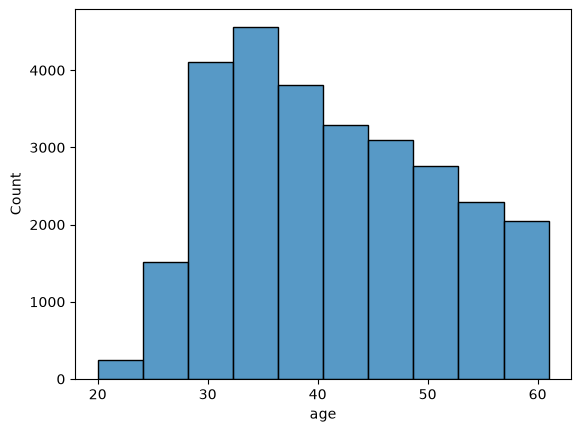

In [7]:
sns.histplot(train['age'], bins = 10)

<Axes: xlabel='balance', ylabel='Count'>

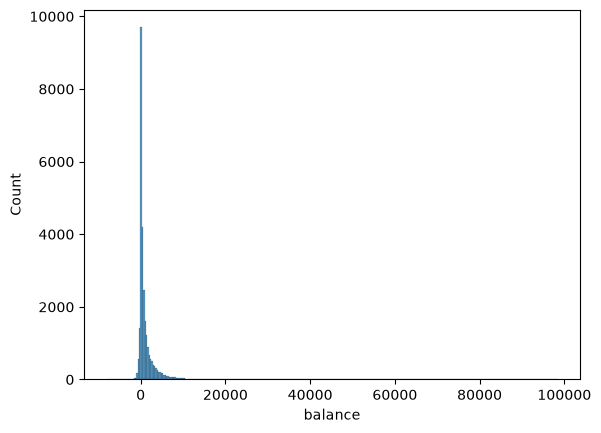

In [8]:
sns.histplot(train['balance'])

<Axes: xlabel='balance', ylabel='Count'>

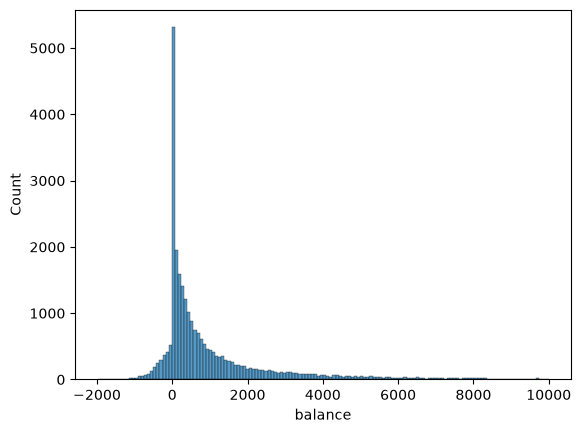

In [9]:
sns.histplot(train[(train['balance'] < 10000) & (train['balance'] > -2000)]['balance'])

<Axes: xlabel='duration', ylabel='Count'>

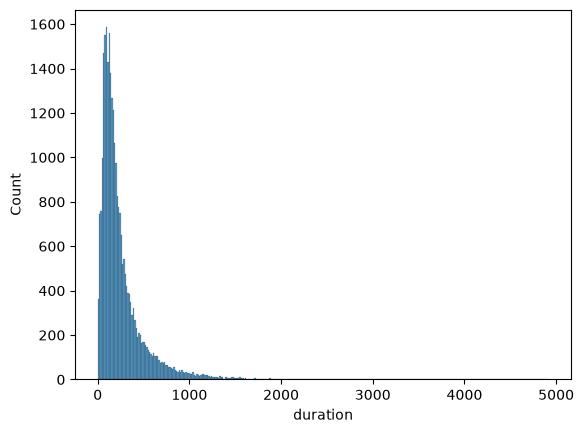

In [10]:
sns.histplot(train['duration'])

<Axes: xlabel='campaign', ylabel='Count'>

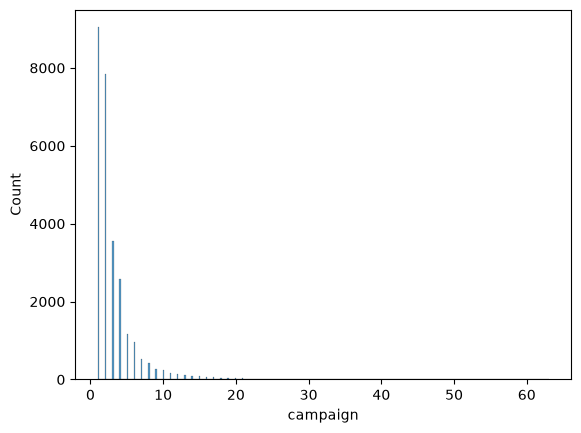

In [11]:
sns.histplot(train['campaign'])

<Axes: xlabel='pdays', ylabel='Count'>

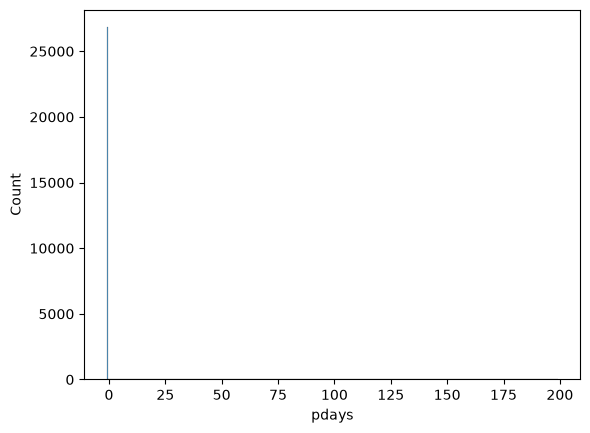

In [12]:
sns.histplot(train['pdays'])

<Axes: xlabel='pdays', ylabel='Count'>

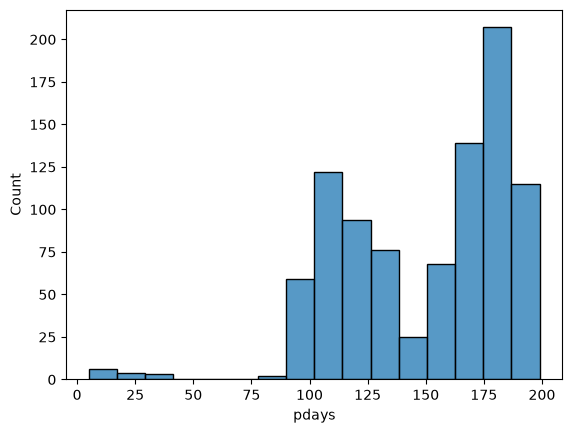

In [13]:
sns.histplot(train[train['pdays'] != -1]['pdays'])

<Axes: xlabel='previous', ylabel='Count'>

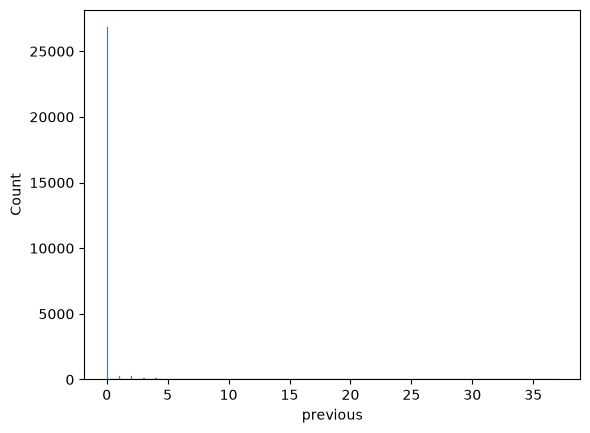

In [14]:
sns.histplot(train['previous'])

<Axes: xlabel='previous', ylabel='Count'>

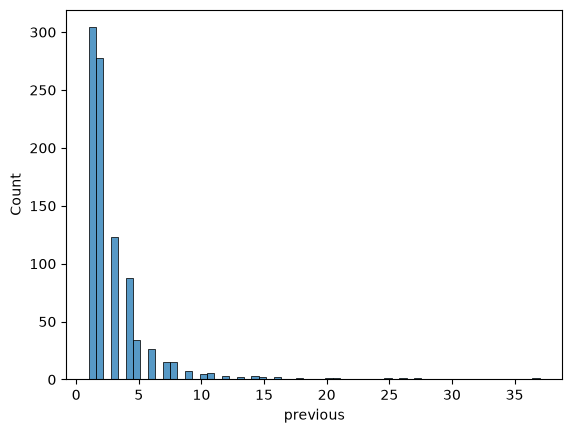

In [15]:
sns.histplot(train[train['previous'] > 0]['previous'])

Most of the (non-temporal) numeric columns are skewed to the right, which may require transformrations to reduce the outlying values for model training

## Bivariate Distirbutions

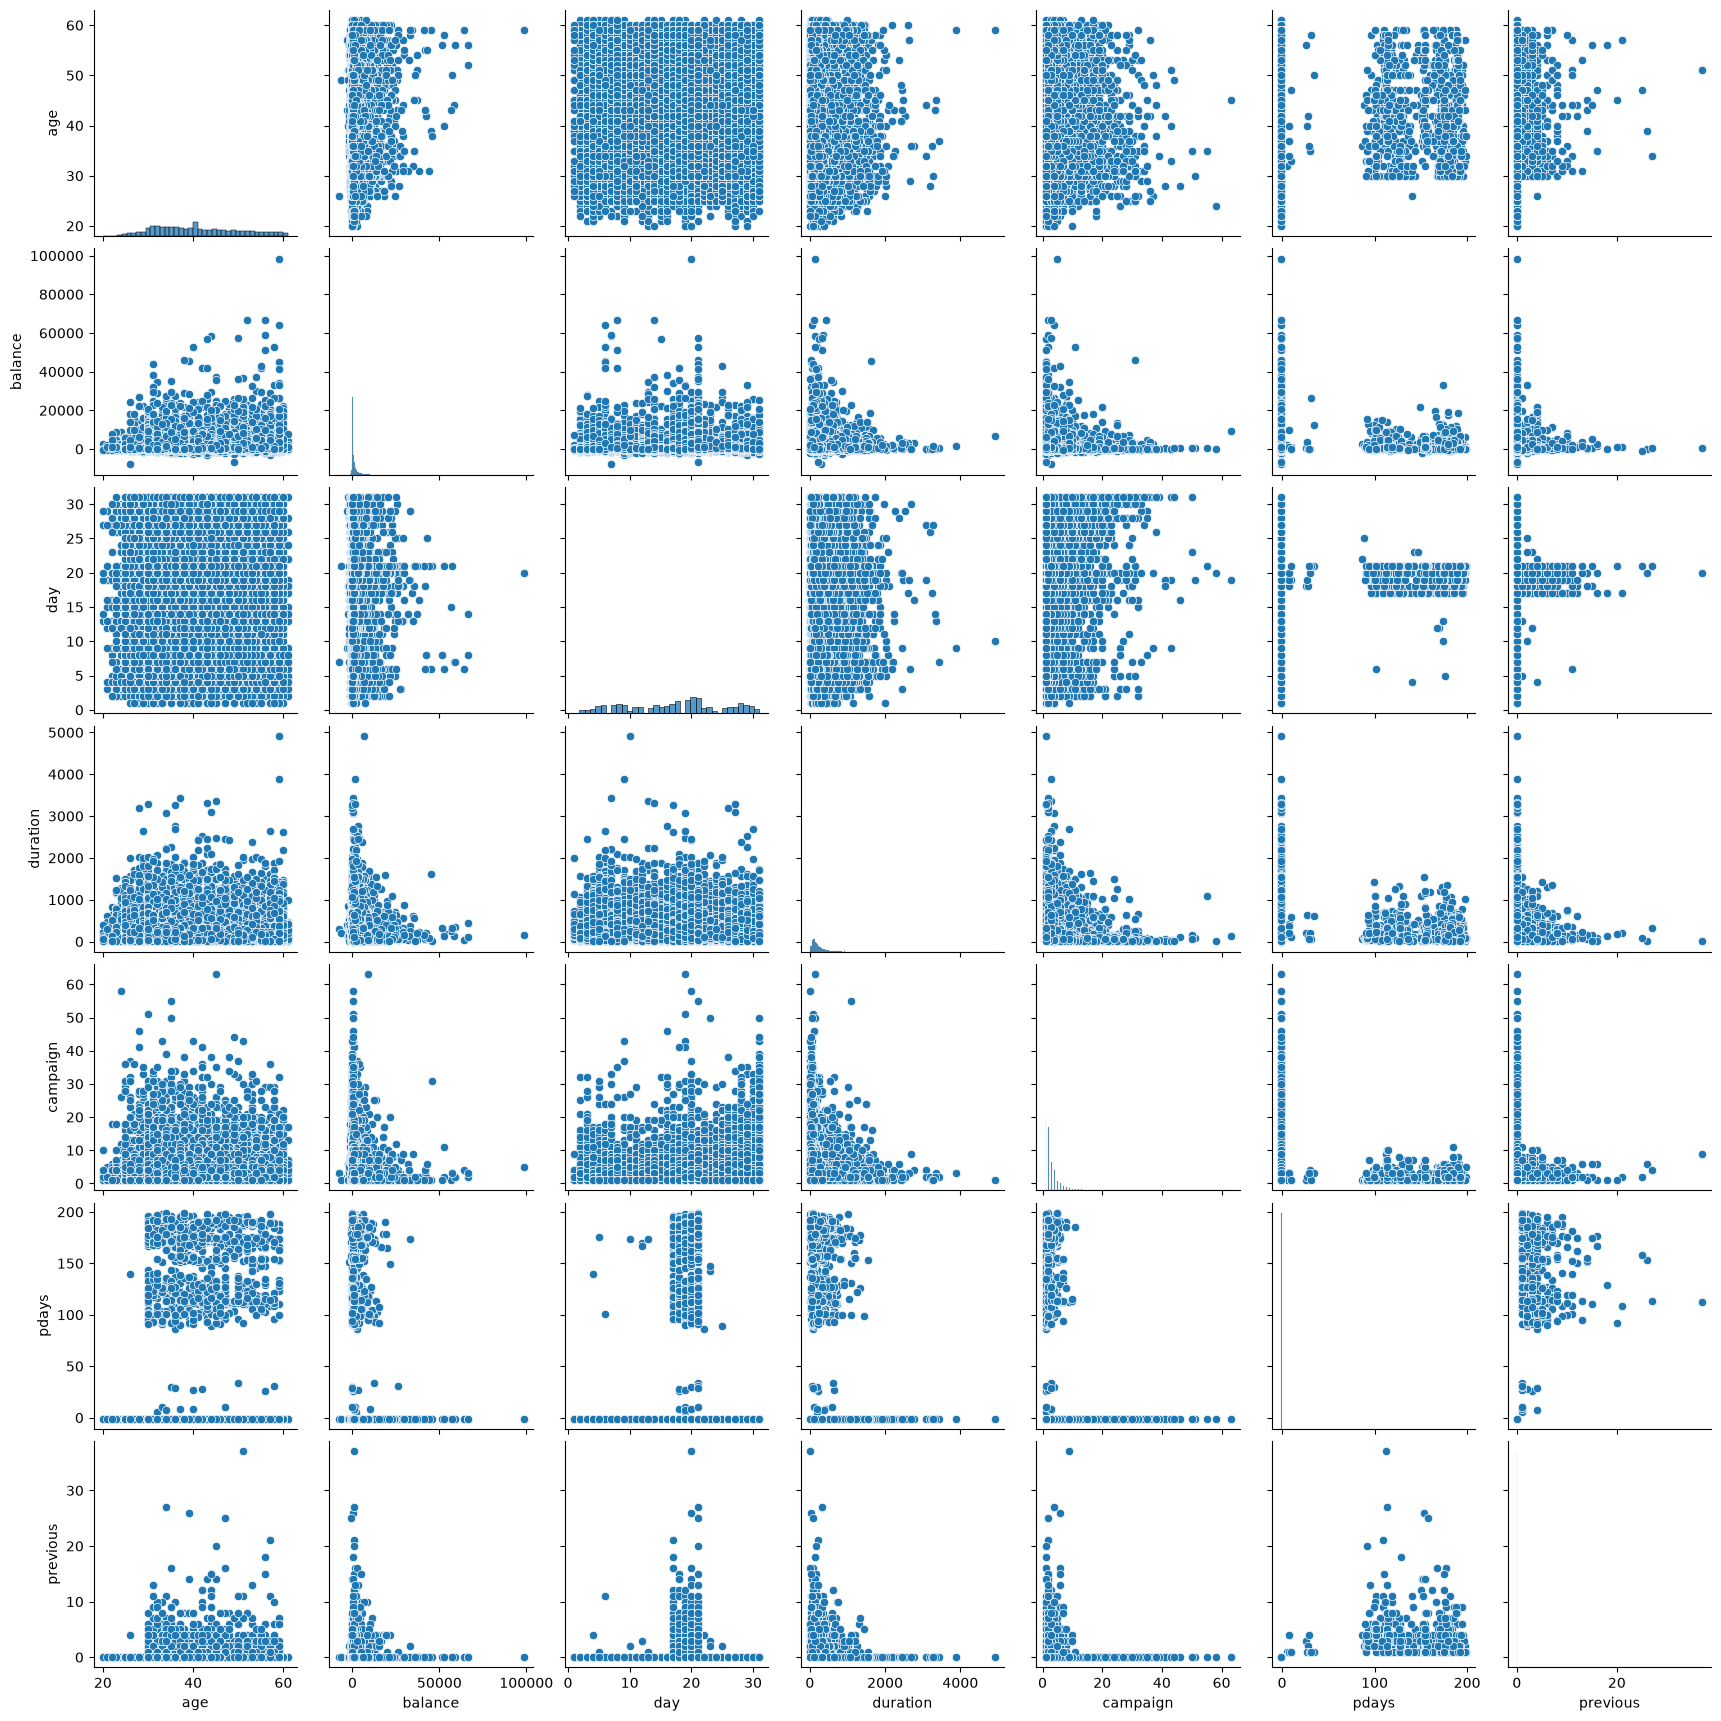

In [16]:
sns.pairplot(train)

<Axes: >

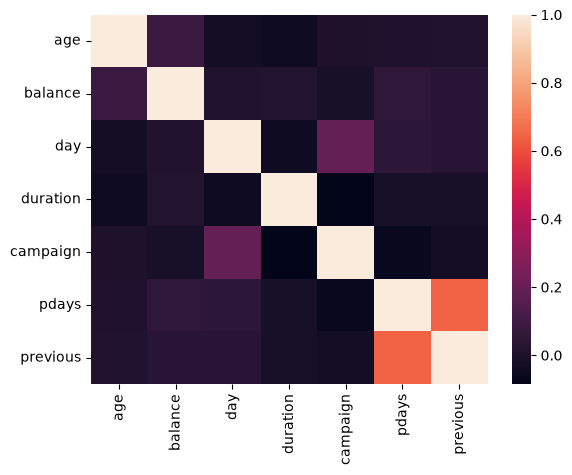

In [17]:
sns.heatmap(train.corr(numeric_only = True))

From the pairplot, most of the points are scattered rectangularly, meaning there is no linear relationship, however, from the correlation heatmap, pdays and previous have moderate correlation, which may be a problem with regression models. These columns should be considered for joint transformation or feature extraction to reduce information redundancy and multicollinearity.

In [18]:
train.describe(exclude='number').T

,count,unique,top,freq
job,27729,12,blue-collar,6349
marital,27729,3,married,17751
education,27729,4,secondary,14297
default,27729,2,no,27059
housing,27729,2,yes,15486
loan,27729,2,no,22535
contact,27729,3,cellular,13625
month,27729,7,may,7957
poutcome,27729,4,unknown,26809
y,27729,2,no,26328


<Axes: xlabel='count', ylabel='marital'>

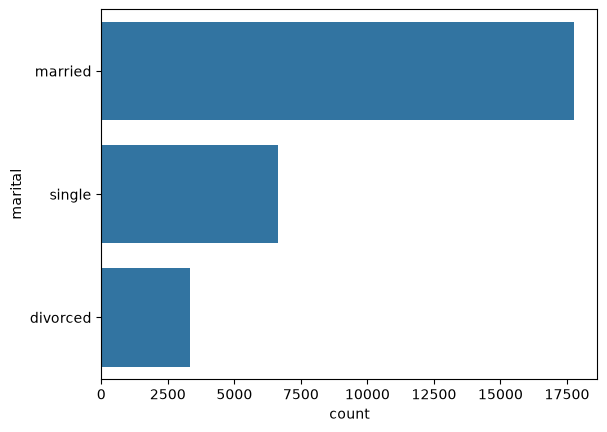

In [19]:
sns.countplot(train, y = 'marital', order = train['marital'].value_counts().index)

<Axes: xlabel='count', ylabel='job'>

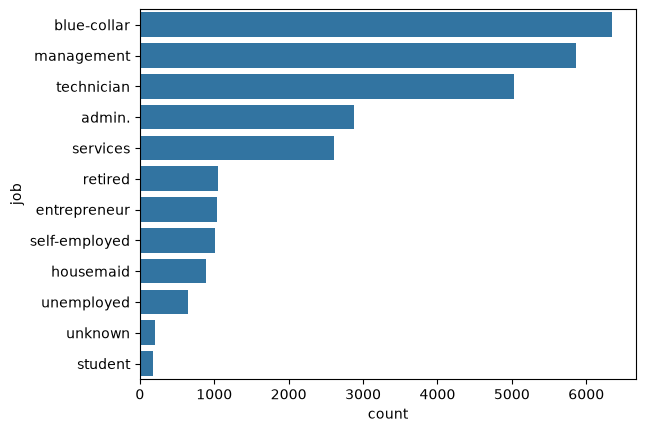

In [20]:
sns.countplot(train, y = 'job', order = train['job'].value_counts().index)

There is a significant decrease in counts when it comes to retired, entrepeneur, self-employed, housemaid, unemployed, and student. It may be worth considering to create groupings to avoid count imbalances during model training, and to reduce the number of features after dummy encoding.

<Axes: xlabel='count', ylabel='education'>

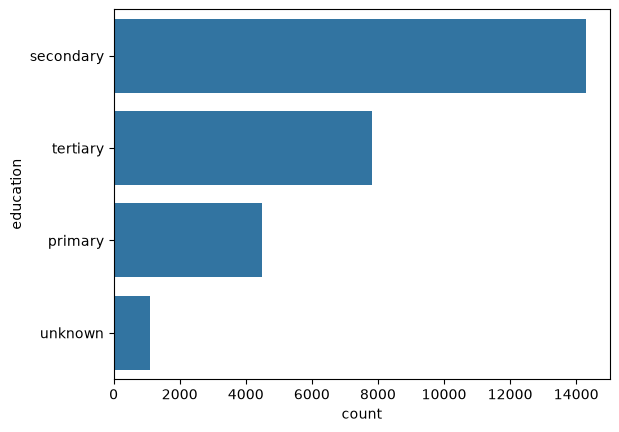

In [21]:
sns.countplot(train, y = 'education', order = train['education'].value_counts().index)

<Axes: xlabel='count', ylabel='contact'>

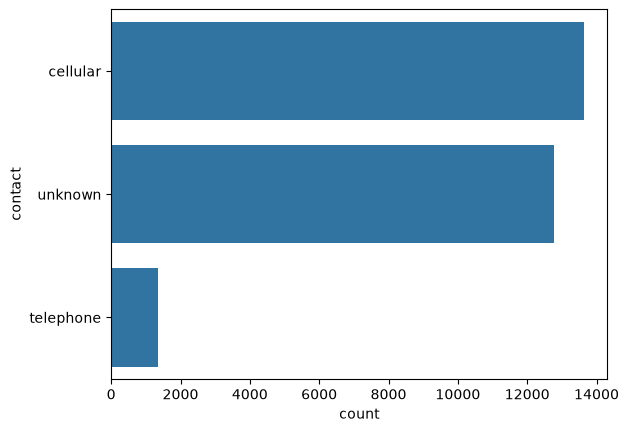

In [22]:
sns.countplot(train, y = 'contact', order = train['contact'].value_counts().index)

## Data Exploration Insights
- **Skewness of numeric columns:** Most of the columns are right-skewed showcasing evidence of severe outliers. 
- **Uncorrelatedness of most numeric columns:** 
- **Temporal Observations** December has low values. Requiring merging to Quarter level due to feature imbalance. Day of month does not seem interesting to provide new information
- **First-time Contact with Customers:** A lot of the values


# Feature Engineering

y (marketing outcome) is currently a string, so i convert it into a boolean

In [23]:
train['y'] = train['y'] == "yes"
test['y'] = test['y'] == "yes"

I choose to group the job descriptions with the following mapping to address groups with relatively low counts

In [24]:
job_mapping = {
    'management': 'management',
    'technician': 'technician',
    'admin.': 'admin.',
    'services': 'services',
    'blue-collar': 'blue-collar',
    'entrepreneur': 'business-owner',
    'self-employed': 'business-owner',
    'retired': 'non-working',
    'unemployed': 'non-working',
    'student': 'non-working',
    'housemaid': 'services',
    'unknown': 'unknown'
}

train['job_group'] = train['job'].map(job_mapping)
test['job_group'] = test['job'].map(job_mapping)

visualization of new job column

<Axes: xlabel='count', ylabel='job_group'>

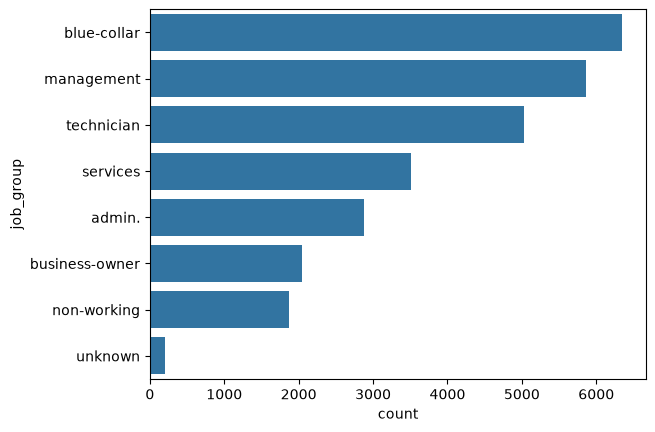

In [25]:
sns.countplot(train, y = 'job_group', order = train['job_group'].value_counts().index)

choosing relevant variables, remove prevcious campaigning informaiton (high missingness). remove temporal variables

In [26]:
retained_variables = ['age','job_group','education','default','balance','housing','loan','contact','y']
train = train[retained_variables]
test = test[retained_variables]

scaling. robustscaling was chosen due to skewness of data with high outliers

In [27]:
numeric_cols = train.select_dtypes(include=['number']).columns
scaler = RobustScaler()
train[numeric_cols] = scaler.fit_transform(train[numeric_cols])
test[numeric_cols] = scaler.transform(test[numeric_cols])

/var/folders/vq/cryv6vjx08g3ynjl7lfwb02m0000gp/T/ipykernel_54962/3385176543.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[numeric_cols] = scaler.fit_transform(train[numeric_cols])


In [28]:
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

In [29]:
X_train = train.drop(columns = 'y')
y_train = train.y
X_test = test.drop(columns = 'y')
y_test = test.y

balancing using SMOTE resampling

In [37]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

2026/06/28 09:40:26 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4d10fc9f22684620b2262ebfc6d250a7', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/28 09:40:26 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/06/28 09:40:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/28 09:40:26 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/06/28 09:40:28 WARNI

In [30]:
train.shape

(27729, 18)

In [31]:
train.head(1)

,age,balance,y,job_group_blue-collar,job_group_business-owner,job_group_management,job_group_non-working,job_group_services,job_group_technician,job_group_unknown,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown
0,1.125,1.330053,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True


# Model Training

# Model Building using LogisticRegression

In [32]:
X_test['contact_unknown'] = False

In [38]:
mlflow.sklearn.autolog()
lr = LogisticRegression()
lr.fit(X_train_resampled, y_train_resampled)
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))

2026/06/28 09:41:08 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'b1aef867a50d43ad8dc61c25fe66aecb', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/28 09:41:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/Users/side_a/Documents/projects_personal/bank-telemarketing/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


              precision    recall  f1-score   support

       False       0.88      0.30      0.45     11022
        True       0.13      0.72      0.22      1643

    accuracy                           0.35     12665
   macro avg       0.51      0.51      0.34     12665
weighted avg       0.78      0.35      0.42     12665



# Model Building using XGBoost

In [39]:
mlflow.xgboost.autolog()
xgb = XGBClassifier()
xgb.fit(X_train_resampled, y_train_resampled)

2026/06/28 09:41:13 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9c7076ce1d344254aae4fc216fb566d9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/06/28 09:41:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.87      0.95      0.91     11022
        True       0.15      0.06      0.08      1643

    accuracy                           0.84     12665
   macro avg       0.51      0.50      0.50     12665
weighted avg       0.78      0.84      0.80     12665



Looking at the (True) recall rates, clasifier performed better than the XGBoost model. Thus, the default logistic regresison model will be used for deployment

# Model Tuning

In [ ]:
param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': np.logspace(-4, 4, 9)
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-4, 4, 9)
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': np.logspace(-4, 4, 9),
        'l1_ratio': [0.5]  # Only required if penalty is 'elasticnet'
    }
]

# 5. Initialize GridSearchCV
# cv=5 means 5-fold cross-validation, n_jobs=-1 uses all available processor cores
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)

# 6. Fit the grid search to find the best hyperparameters
grid_search.fit(X_train_resampled, y_train_resampled)

# 7. Extract the top-performing attributes
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best CV Recall Score: {grid_search.best_score_:.4f}")

# 8. Evaluate the best model on test data
best_model = grid_search.best_estimator_

2026/06/28 09:46:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '17a8d26c6b6c4082a43ee5d84533e42e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
/Users/side_a/Documents/projects_personal/bank-telemarketing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/side_a/Documents/projects_personal/bank-telemarketing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.

Best Hyperparameters: {'C': np.float64(0.0001), 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
Best CV Accuracy Score: 0.8000


In [47]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00     11022
        True       0.13      1.00      0.23      1643

    accuracy                           0.13     12665
   macro avg       0.06      0.50      0.11     12665
weighted avg       0.02      0.13      0.03     12665



/Users/side_a/Documents/projects_personal/bank-telemarketing/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/side_a/Documents/projects_personal/bank-telemarketing/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/side_a/Documents/projects_personal/bank-telemarketing/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

Thus, the best hyperparameters is solved with a cross-validation recall score of 0.8. However, it showed a 100% recall score, which is suspicious.

I will use the basic logistic regression classifier for deployment since the goal of this project is model deployment more than model development

Now, the contents of these notebooks are modularized